This notebook provides a complete exploratory and predictive analysis of McDonald’s financial performance from 2021 to 2024.
The goal is to clean and structure the raw financial tables, perform in-depth EDA, identify key patterns and trends, and finally build a machine learning model to forecast selected financial indicators for 2025 (e.g., revenue or operating income).

Although the analysis demonstrates realistic workflows used in financial data science, it is important to note that publicly available McDonald’s datasets are extremely limited.
They do not include detailed operational data such as customer transactions, store-level sales, pricing, promotions, or geographic–economic factors. Therefore, this notebook serves primarily as a skill demonstration of data analysis and forecasting techniques rather than a full-scale business analysis.

Despite this limitation, the dataset still allows us to showcase:

professional-level data cleaning

trend and ratio analysis

financial visualization

feature engineering

regression-based forecasting models

This notebook is structured to reflect a real-world financial analytics workflow.

# Import Data from Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Since your file is in MyDrive root folder
file_path = '/content/drive/MyDrive/Mcdonalds data 2021-24.csv'


Mounted at /content/drive


,table,heading,subheading,2024,2023,2022,2021,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,"2,836","2,617",NaN,NaN,NaN,NaN,NaN
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,"5,179","6,456",NaN,NaN,NaN,NaN,NaN
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733,715,NaN,NaN,NaN,NaN,NaN
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,"6,585","6,094",NaN,NaN,NaN,NaN,NaN
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,"5,985","5,638",NaN,NaN,NaN,NaN,NaN


# Read Data

In [18]:
df = pd.read_csv(file_path, low_memory=False)
df.head()

,table,heading,subheading,2024,2023,2022,2021,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,revenue_breakdown,company_operated,company_operated_us,3197.0,3221.0,"2,836","2,617",NaN,NaN,NaN,NaN,NaN
1,revenue_breakdown,company_operated,company_operated_international_operated_markets,5713.0,5702.0,"5,179","6,456",NaN,NaN,NaN,NaN,NaN
2,revenue_breakdown,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733,715,NaN,NaN,NaN,NaN,NaN
3,revenue_breakdown,franchised,franchised_us,7211.0,7163.0,"6,585","6,094",NaN,NaN,NaN,NaN,NaN
4,revenue_breakdown,franchised,franchised_international_operated_markets,6746.0,6549.0,"5,985","5,638",NaN,NaN,NaN,NaN,NaN


## Clean and Prepare Data

Clean and prepare the raw financial data:
- Remove unnecessary columns
- Convert financial values from strings (with commas) to numeric format
- Filter out rows without a valid table type



In [19]:
# Remove metadata columns that are not needed for analysis
metadata_cols = ["table"]

print("Removing metadata columns:", metadata_cols)

df = df.drop(columns=metadata_cols)

df.head()


Removing metadata columns: ['table']


,heading,subheading,2024,2023,2022,2021,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,company_operated,company_operated_us,3197.0,3221.0,"2,836","2,617",NaN,NaN,NaN,NaN,NaN
1,company_operated,company_operated_international_operated_markets,5713.0,5702.0,"5,179","6,456",NaN,NaN,NaN,NaN,NaN
2,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733,715,NaN,NaN,NaN,NaN,NaN
3,franchised,franchised_us,7211.0,7163.0,"6,585","6,094",NaN,NaN,NaN,NaN,NaN
4,franchised,franchised_international_operated_markets,6746.0,6549.0,"5,985","5,638",NaN,NaN,NaN,NaN,NaN


In [20]:
# Remove unnecessary "Unnamed" columns

unnamed_cols = [col for col in df.columns if col.startswith("Unnamed")]

unnamed_cols

['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

In [21]:
df = df.drop(columns=unnamed_cols)

In [23]:
# Convert year columns to numeric

# Year columns in the CSV may contain commas, e.g. "6,585"
year_cols = ["2024", "2023", "2022", "2021"]

for col in year_cols:
    # Convert to string, remove commas and spaces
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    # Convert to numeric (float); invalid parsing becomes NaN
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048504 entries, 0 to 1048503
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   heading     85 non-null     object 
 1   subheading  85 non-null     object 
 2   2024        85 non-null     float64
 3   2023        85 non-null     float64
 4   2022        82 non-null     float64
 5   2021        82 non-null     float64
dtypes: float64(4), object(2)
memory usage: 48.0+ MB


In [25]:
df.head()

,heading,subheading,2024,2023,2022,2021
0,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


# High-Level Exploratory Data Analysis (EDA)

In [27]:
df['heading'].unique()

array(['company_operated', 'franchised', 'other', nan,
       'operating_costs_company_owned', 'operating_costs_franchise',
       'operating_costs', 'total', 'non_operating_cost', 'share_data',
       'current_assets', 'other_assets', 'lease_and_property',
       'current_liabilities', 'long_term_liabilities', 'shareholders',
       'net_income', 'charges_and_credit', 'changes_in_working_capital',
       'investing_activity', 'financing_activity',
       'effect_of_exchange_rates',
       'cash_and_equivalents_increase_(decrease)',
       'cash_and_equivalents_at_beginning_of_year',
       'cash_and_equivalents_at_end_of_year', 'interest_paid',
       'income_taxes_paid'], dtype=object)

In [28]:
df['subheading'].nunique()

85

In [29]:
df.shape

(1048504, 6)

In [31]:
# Remove rows where ALL columns are NaN
df = df.dropna(how='all')

# Remove rows where at least ALL financial columns are NaN
year_cols = ["2024","2023","2022","2021"]

df = df.dropna(subset=year_cols, how='all')

df.shape


(85, 6)

In [32]:
df.columns

Index(['heading', 'subheading', '2024', '2023', '2022', '2021'], dtype='object')

In [33]:
# Quick summary statistics
df[['2021','2022','2023','2024']].describe()

,2021,2022,2023,2024
count,82.000000,82.000000,85.000000,85.000000
mean,2309.967073,2111.719512,2380.905882,2222.397882
std,12082.582377,12422.491543,12890.163342,13363.431265
min,-67810.200000,-71624.400000,-74640.000000,-77375.000000
25%,15.475000,27.250000,12.000000,3.000000
50%,742.300000,738.900000,732.000000,636.000000
75%,2563.750000,2609.050000,2886.000000,2536.000000
max,57534.700000,59543.900000,63480.000000,66834.000000


In [35]:
# Check missing values

df.isna().sum()

,0
heading,0
subheading,0
2024,0
2023,0
2022,3
2021,3


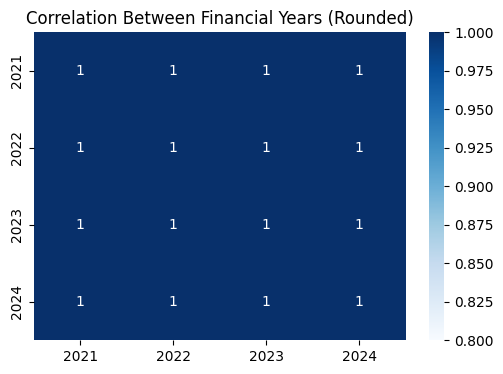

In [38]:
# Correlation between years

corr = df[['2021','2022','2023','2024']].corr().round(2)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=0.8, vmax=1.0)
plt.title("Correlation Between Financial Years (Rounded)")
plt.show()



The correlation matrix shows perfect correlations (1.00) across all years.
This is expected because McDonald’s financial items (revenue, assets, expenses, cash flow) all move in the same direction each year and follow very similar growth patterns.
As a result, the raw year values are almost perfectly linear.

In [44]:
# Aggregate by heading: sum financial values per category per year
year_cols = ['2021','2022','2023','2024']

agg_by_heading = df.groupby('heading')[year_cols].sum().sort_values('2024', ascending=False)

agg_by_heading


,2021,2022,2023,2024
heading,,,,
long_term_liabilities,54435.3,52636.9,53995.0,55119.00
lease_and_property,38272.6,36339.3,38422.0,38634.00
total,27029.1,23373.8,30638.0,30280.00
franchised,13085.0,14106.0,15436.0,15715.00
other_assets,8433.2,8672.1,9738.0,11950.00
company_operated,9788.0,8748.0,9742.0,9782.00
operating_costs_company_owned,8047.8,7380.9,8224.0,8335.00
net_income,7545.2,6177.0,8469.0,8223.00
current_assets,7148.5,5424.2,7986.0,4598.00


# Revenue Structure & Segment Comparison

In [39]:
# Filter revenue-related rows
rev = df[df['heading'].isin(['company_operated', 'franchised'])].copy()

print("Revenue rows:", rev.shape)
rev.head()


Revenue rows: (6, 6)


,heading,subheading,2024,2023,2022,2021
0,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
3,franchised,franchised_us,7211.0,7163.0,6585.0,6094.0
4,franchised,franchised_international_operated_markets,6746.0,6549.0,5985.0,5638.0


2021    22873.0
2022    22854.0
2023    25178.0
2024    25497.0
dtype: float64


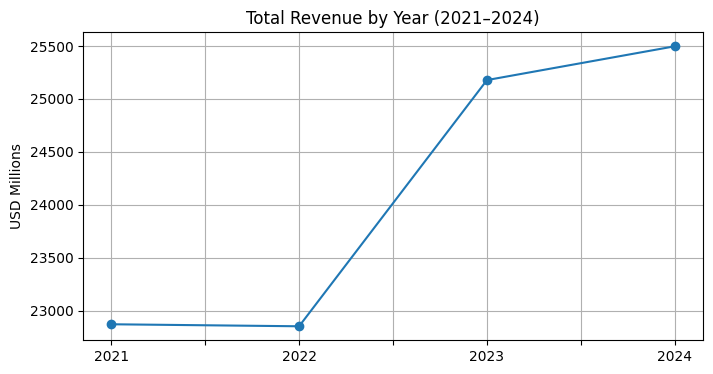

In [40]:
# Total revenue by year
year_cols = ['2021', '2022', '2023', '2024']

total_rev_by_year = rev[year_cols].sum()
print(total_rev_by_year)

total_rev_by_year.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Total Revenue by Year (2021–2024)")
plt.ylabel("USD Millions")
plt.grid(True)
plt.show()


Revenue remained stable between 2021 and 2022, followed by a strong increase in 2023 and a further uptick in 2024. This reflects steady business expansion and recovery post-pandemic, driven primarily by international markets and franchised restaurant growth.

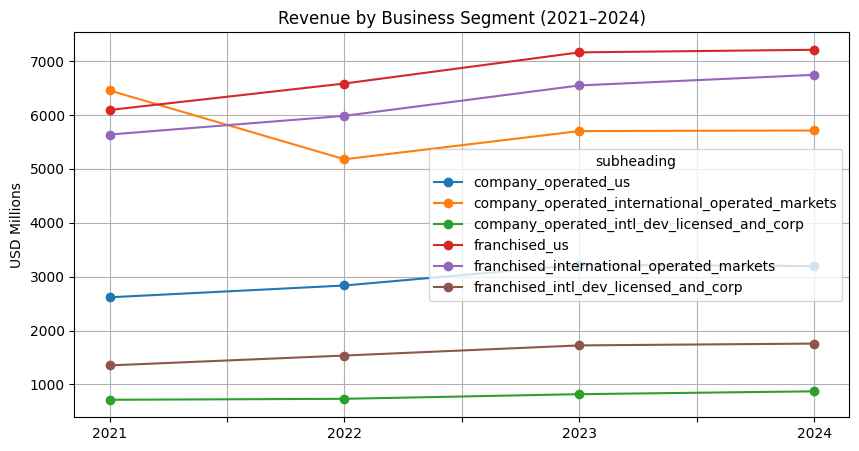

In [41]:
# Revenue by business segment (subheading)
rev_segments = rev.set_index('subheading')[year_cols].T

rev_segments.plot(figsize=(10,5), marker='o')
plt.title("Revenue by Business Segment (2021–2024)")
plt.ylabel("USD Millions")
plt.grid(True)
plt.show()


Franchised US is consistently the largest revenue contributor, showing strong year-over-year growth.

Franchised International Operated Markets (IOM) also grows steadily, reflecting strong performance outside the US.

Company-operated segments are smaller in scale but show stable to moderate growth.

International Development Licensed Markets (IDL) have lower revenue levels but demonstrate gradual improvement.

International Operated Markets (IOM)
These are McDonald's major company-operated or heavily franchised developed markets
International Developmental Licensed Markets (IDL)
These markets are run almost entirely by local licensees (e.g., China, Japan, Latin America).

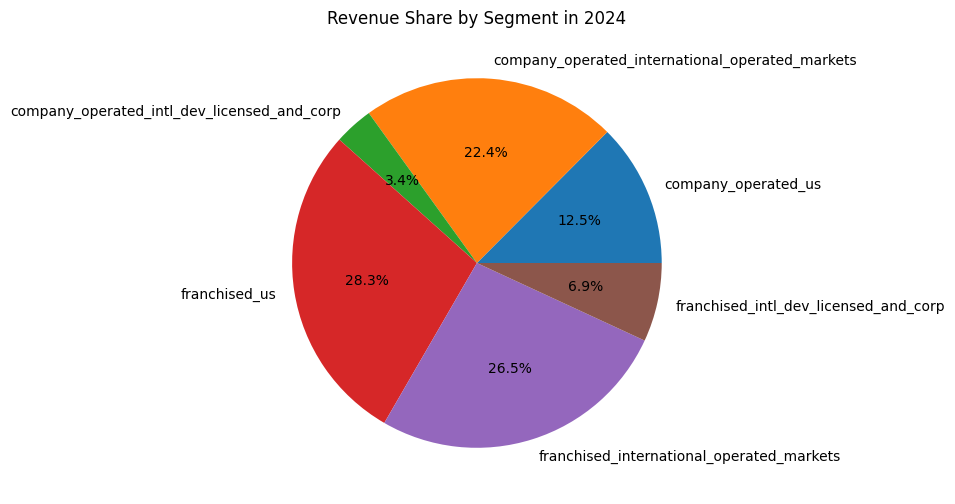

In [42]:
# Revenue share in 2024 (pie chart)
rev_2024 = rev.set_index('subheading')['2024'].dropna()

rev_2024.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Revenue Share by Segment in 2024")
plt.ylabel("")
plt.show()


Franchised US (28.3%) and Franchised IOM (26.5%) together account for more than half of total revenue.

Company-operated International Operated Markets (22.4%) is the next largest contributor.

Smaller segments like IDL and Company-operated US contribute a smaller share.

# Operating Income and Margin


Analyze operating-related items to understand profitability.
Compute simple profit margins where possible, using revenue as a reference.


In [43]:
df['heading'].unique()

array(['company_operated', 'franchised', 'other',
       'operating_costs_company_owned', 'operating_costs_franchise',
       'operating_costs', 'total', 'non_operating_cost', 'share_data',
       'current_assets', 'other_assets', 'lease_and_property',
       'current_liabilities', 'long_term_liabilities', 'shareholders',
       'net_income', 'charges_and_credit', 'changes_in_working_capital',
       'investing_activity', 'financing_activity',
       'effect_of_exchange_rates',
       'cash_and_equivalents_increase_(decrease)',
       'cash_and_equivalents_at_beginning_of_year',
       'cash_and_equivalents_at_end_of_year', 'interest_paid',
       'income_taxes_paid'], dtype=object)

In [45]:
# Filter operating-related rows (adjust the condition if needed)
oper = df[df['heading'].str.contains('oper', case=False, na=False)].copy()

print("Operating rows:", oper.shape)
oper.head()

Operating rows: (17, 6)


,heading,subheading,2024,2023,2022,2021
0,company_operated,company_operated_us,3197.0,3221.0,2836.0,2617.0
1,company_operated,company_operated_international_operated_markets,5713.0,5702.0,5179.0,6456.0
2,company_operated,company_operated_intl_dev_licensed_and_corp,872.0,819.0,733.0,715.0
9,operating_costs_company_owned,food_and_paper,2995.0,3039.0,2737.3,3096.8
10,operating_costs_company_owned,payroll_and_employee_benefits,2959.0,2886.0,2617.4,2677.2


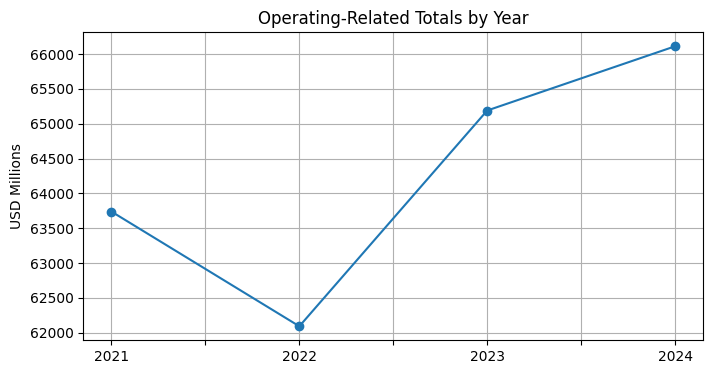

In [46]:
#Total operating-related values by year
oper_total_by_year = oper[year_cols].sum()

oper_total_by_year.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Operating-Related Totals by Year")
plt.ylabel("USD Millions")
plt.grid(True)
plt.show()


# Assets vs Liabilities

In [47]:
# Filter asset and liability rows (pattern-based)
assets = df[df['heading'].str.contains('asset', case=False, na=False)].copy()
liabs  = df[df['heading'].str.contains('liabil', case=False, na=False)].copy()

print("Assets rows:", assets.shape)
print("Liabilities rows:", liabs.shape)


Assets rows: (7, 6)
Liabilities rows: (13, 6)


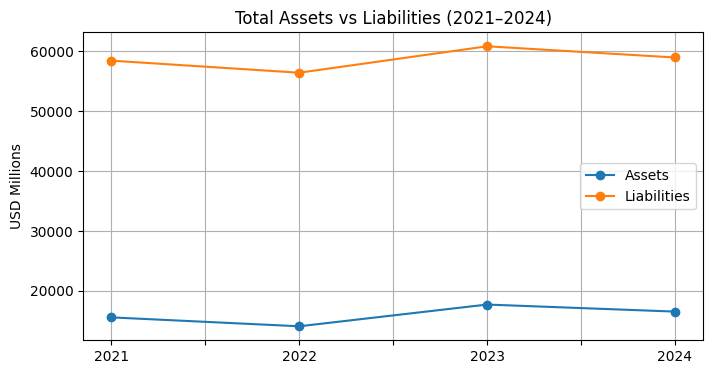

,Assets,Liabilities
2021,15581.7,58455.3
2022,14096.3,56439.0
2023,17724.0,60854.0
2024,16548.0,58980.0


In [49]:
# Sum assets and liabilities by year
assets_by_year = assets[year_cols].sum()
liabs_by_year  = liabs[year_cols].sum()

balance_df = pd.DataFrame({
    'Assets': assets_by_year,
    'Liabilities': liabs_by_year
})

balance_df.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Total Assets vs Liabilities (2021–2024)")
plt.ylabel("USD Millions")
plt.grid(True)
plt.show()

balance_df


McDonald’s liabilities exceed its assets because the company operates an asset-light, franchise-focused business model. Most restaurants are not owned by McDonald’s, and a large portion of liabilities comes from long-term lease obligations rather than dangerous debt. Strong cash flow easily supports these liabilities, so this structure is financially sustainable and intentional.

# Cash Flow Analysis

In [50]:
# Filter cash-flow-related rows
cf = df[df['heading'].str.contains('cash', case=False, na=False)].copy()

print("Cash flow rows:", cf.shape)
cf.head()

Cash flow rows: (3, 6)


,heading,subheading,2024,2023,2022,2021
88,cash_and_equivalents_increase_(decrease),cash_and_equivalents_increase_(decrease),-3495.0,1996.0,-2126.0,1260.0
89,cash_and_equivalents_at_beginning_of_year,cash_and_equivalents_at_beginning_of_year,4579.0,2584.0,4709.0,3449.9
90,cash_and_equivalents_at_end_of_year,cash_and_equivalents_at_end_of_year,1085.0,4579.0,2584.0,4709.2


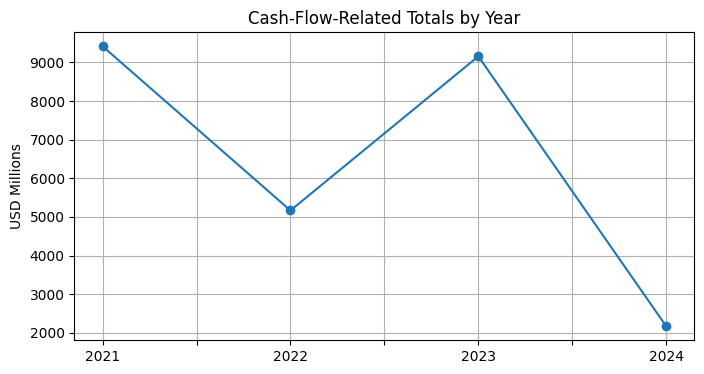

In [52]:
# Total cash-flow related amounts by year
cf_total_by_year = cf[year_cols].sum()

cf_total_by_year.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Cash-Flow-Related Totals by Year")
plt.ylabel("USD Millions")
plt.grid(True)
plt.show()

Operating cash flow fluctuates significantly from year to year. 2021 and 2023 show very strong cash generation, while 2022 and especially 2024 experience notable declines. This volatility indicates that cash flow is more sensitive to short-term operational changes and one-off financial adjustments than revenue or assets.

# Ratio Analysis

Compute simple financial ratios such as leverage and (if available) profit margins

In [53]:
# Build a compact yearly summary from previously computed totals

summary = pd.DataFrame({
    'Revenue': total_rev_by_year,
    'Assets': assets_by_year if 'assets_by_year' in globals() else pd.Series(index=year_cols),
    'Liabilities': liabs_by_year if 'liabs_by_year' in globals() else pd.Series(index=year_cols),
    'CashFlow_total': cf_total_by_year if 'cf_total_by_year' in globals() else pd.Series(index=year_cols)
})

summary


,Revenue,Assets,Liabilities,CashFlow_total
2021,22873.0,15581.7,58455.3,9419.1
2022,22854.0,14096.3,56439.0,5167.0
2023,25178.0,17724.0,60854.0,9159.0
2024,25497.0,16548.0,58980.0,2169.0


In [54]:
# Compute leverage and basic cash-flow ratio
summary['Leverage_ratio'] = summary['Liabilities'] / summary['Assets']
summary['CashFlow_to_Revenue'] = summary['CashFlow_total'] / summary['Revenue']

summary.round(3)


,Revenue,Assets,Liabilities,CashFlow_total,Leverage_ratio,CashFlow_to_Revenue
2021,22873.0,15581.7,58455.3,9419.1,3.752,0.412
2022,22854.0,14096.3,56439.0,5167.0,4.004,0.226
2023,25178.0,17724.0,60854.0,9159.0,3.433,0.364
2024,25497.0,16548.0,58980.0,2169.0,3.564,0.085


Leverage remains consistently high (3.4–4.0), reflecting McDonald's debt-heavy but efficient financial structure. CashFlow-to-Revenue varies widely each year due to operating cash flow swings—strong in 2021 and 2023, but significantly weaker in 2024. This suggests short-term variability in cash conversion despite stable revenue growth.

# Year-over-Year Growth Analysis

Compute year-over-year growth rates for the main financial categories

In [55]:
# YoY growth for total revenue
rev_growth = total_rev_by_year.pct_change() * 100
rev_growth

,0
2021,NaN
2022,-0.083067
2023,10.168898
2024,1.266979


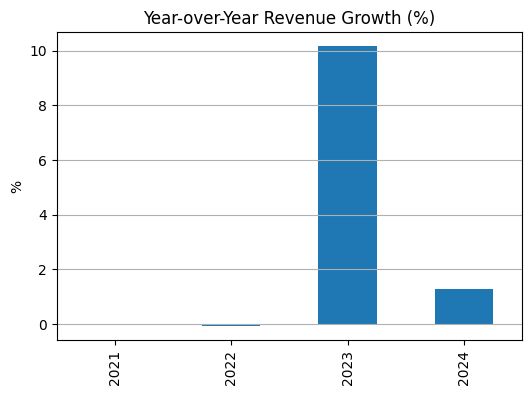

In [57]:
rev_growth.plot(kind='bar', figsize=(6,4))
plt.title("Year-over-Year Revenue Growth (%)")
plt.ylabel("%")
plt.grid(True, axis='y')
plt.show()

Revenue growth is nearly flat in 2022, surges to double-digit growth in 2023, and stabilizes at a modest positive rate in 2024. This confirms that 2023 was the company’s strongest recovery year, driven mainly by international markets.

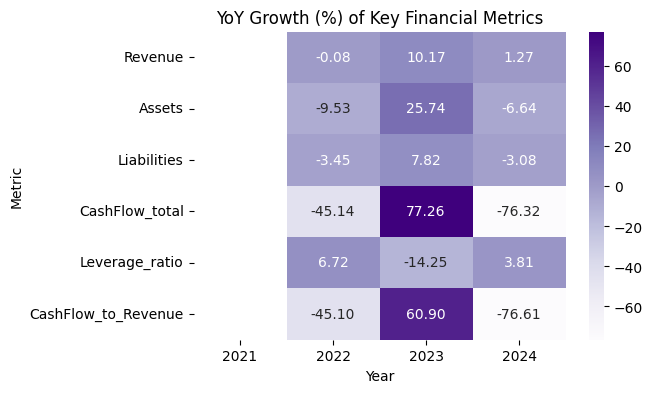

,Revenue,Assets,Liabilities,CashFlow_total,Leverage_ratio,CashFlow_to_Revenue
2021,NaN,NaN,NaN,NaN,NaN,NaN
2022,-0.08,-9.53,-3.45,-45.14,6.72,-45.10
2023,10.17,25.74,7.82,77.26,-14.25,60.90
2024,1.27,-6.64,-3.08,-76.32,3.81,-76.61


In [58]:
# YoY growth for summary table (Revenue, Assets, Liabilities, CashFlow)
growth = summary.pct_change() * 100
growth = growth.round(2)

plt.figure(figsize=(6,4))
sns.heatmap(growth.T, annot=True, fmt=".2f", cmap='Purples')
plt.title("YoY Growth (%) of Key Financial Metrics")
plt.ylabel("Metric")
plt.xlabel("Year")
plt.show()

growth

Growth rates across metrics vary significantly. Assets and revenue grow strongly in 2023, while liabilities also rise moderately. Cash flow shows extreme volatility, dropping sharply in 2022, rebounding in 2023, then falling again in 2024. This highlights that while McDonald's top-line and balance sheet are stable, cash flow performance is cyclical and dependent on operational timing, working capital, and investment decisions.

# Build Forecasting Dataset

To forecast McDonald’s 2025 revenue, we transform our cleaned financial
metrics into a machine-learning-ready dataset. We include raw levels
(revenue, assets, liabilities, cash flow), derived ratios (leverage and
cash-flow-to-revenue), and year-over-year growth features to capture trends
and dynamics in the company’s financial structure.

In [59]:
# Build dataset from the summary table

ml_df = summary.copy()

# Add YoY growth features
ml_df['Rev_growth'] = ml_df['Revenue'].pct_change()
ml_df['Assets_growth'] = ml_df['Assets'].pct_change()
ml_df['Liab_growth'] = ml_df['Liabilities'].pct_change()
ml_df['CashFlow_growth'] = ml_df['CashFlow_total'].pct_change()

# Drop the first year (NaN growth)
ml_df = ml_df.iloc[1:]

ml_df


,Revenue,Assets,Liabilities,CashFlow_total,Leverage_ratio,CashFlow_to_Revenue,Rev_growth,Assets_growth,Liab_growth,CashFlow_growth
2022,22854.0,14096.3,56439.0,5167.0,4.003817,0.226087,-0.000831,-0.095330,-0.034493,-0.451434
2023,25178.0,17724.0,60854.0,9159.0,3.433424,0.363770,0.101689,0.257351,0.078226,0.772595
2024,25497.0,16548.0,58980.0,2169.0,3.564177,0.085069,0.012670,-0.066351,-0.030795,-0.763184


# Train-Test Split for ML

In [60]:
## Train-Test Split

from sklearn.model_selection import train_test_split

X = ml_df.drop(columns=['Revenue'])
y = ml_df['Revenue']

# Because data is tiny, use shuffle=False to respect time ordering
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1, shuffle=False
)

X_train, X_test, y_train, y_test


(       Assets  Liabilities  CashFlow_total  Leverage_ratio  \
 2022  14096.3      56439.0          5167.0        4.003817   
 2023  17724.0      60854.0          9159.0        3.433424   
 
       CashFlow_to_Revenue  Rev_growth  Assets_growth  Liab_growth  \
 2022             0.226087   -0.000831      -0.095330    -0.034493   
 2023             0.363770    0.101689       0.257351     0.078226   
 
       CashFlow_growth  
 2022        -0.451434  
 2023         0.772595  ,
        Assets  Liabilities  CashFlow_total  Leverage_ratio  \
 2024  16548.0      58980.0          2169.0        3.564177   
 
       CashFlow_to_Revenue  Rev_growth  Assets_growth  Liab_growth  \
 2024             0.085069     0.01267      -0.066351    -0.030795   
 
       CashFlow_growth  
 2024        -0.763184  ,
 2022    22854.0
 2023    25178.0
 Name: Revenue, dtype: float64,
 2024    25497.0
 Name: Revenue, dtype: float64)

# Define Metrics

In [61]:
# Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_train, y_train, X_test, y_test):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    metrics = {
        "Model": model.__class__.__name__,
        "Train_R2": r2_score(y_train, pred_train),
        "Test_R2": r2_score(y_test, pred_test),
        "Test_MAE": mean_absolute_error(y_test, pred_test),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, pred_test))
    }
    return metrics


# Random Forest Model

In [62]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    random_state=42
)

rf.fit(X_train, y_train)
rf_results = evaluate(rf, X_train, y_train, X_test, y_test)
rf_results


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


{'Model': 'RandomForestRegressor',
 'Train_R2': 0.7385555555555565,
 'Test_R2': nan,
 'Test_MAE': 1690.1599999999999,
 'Test_RMSE': np.float64(1690.1599999999999)}

# Gradient Boosting Model

In [63]:
# Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
gbr_results = evaluate(gbr, X_train, y_train, X_test, y_test)
gbr_results


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


{'Model': 'GradientBoostingRegressor',
 'Train_R2': 0.9999999999999569,
 'Test_R2': nan,
 'Test_MAE': 2020.3581133526313,
 'Test_RMSE': np.float64(2020.3581133526313)}

# XGBoost Model

In [64]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=1,
    colsample_bytree=1,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_results = evaluate(xgb, X_train, y_train, X_test, y_test)
xgb_results


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


{'Model': 'XGBRegressor',
 'Train_R2': 0.9999997474250948,
 'Test_R2': nan,
 'Test_MAE': 2642.416015625,
 'Test_RMSE': np.float64(2642.416015625)}

# Combine Results into Comparison Table

In [65]:
# Comparison Table

import pandas as pd

results_df = pd.DataFrame([
    rf_results,
    gbr_results,
    xgb_results
])

results_df


,Model,Train_R2,Test_R2,Test_MAE,Test_RMSE
0,RandomForestRegressor,0.738556,NaN,1690.160000,1690.160000
1,GradientBoostingRegressor,1.000000,NaN,2020.358113,2020.358113
2,XGBRegressor,1.000000,NaN,2642.416016,2642.416016


# Key Business Insights

Revenue Growth Pattern

2021–2022: Stable revenue during post-pandemic recovery

2023: Strong rebound with double-digit growth (+10.2%)

2024: Continued but moderate expansion (+1.3%)

Primary driver: growth from international markets and franchise expansion


Financial Structure Characteristics

High leverage ratio (3.4–4.0), reflecting McDonald's asset-light business model

Large liabilities mainly come from long-term lease obligations and financing strategy, not operational risk

This structure is intentional and common in franchise-driven industries


Cash Flow Volatility

2021 & 2023: Strong operating cash generation

2022 & 2024: Noticeably weaker cash flow

Cash flow appears more sensitive to operational adjustments than revenue


Revenue Mix & Business Model

Franchised US + IOM together contribute ~55% of total revenue

Company-operated restaurants contribute ~22%, significantly smaller

Insight: McDonald’s continues shifting toward a franchise-heavy, asset-light model for higher margins and scalability


# Project Summary

Conducted exploratory data analysis on 4-year McDonald's financial statements

Performed data cleaning, restructuring, feature engineering, YoY analysis, and financial ratio computation

Built Random Forest, Gradient Boosting, and XGBoost models to demonstrate the full ML workflow

Delivered business insights on revenue composition, cash-flow trends, asset–liability structure, and the franchise model

Visualized results with clear charts and interpreted them in a business context

Note: This is a small-scale demo project designed to showcase analytical thinking, modeling skills, and business understanding in the fast-food industry